# Phase quantitification by XRD

Measured a mixture of two powders:
 - $P_1$: a mixture of vaterite and calcite (around ~5%, but unknown)
 - $P_2$: pure calcite
 
Determined the intensity ratio of the main vaterite ($I_v$) and calcite ($I_c$) peaks, $\frac{I_v}{I_c}$, which is linearly related to the fractional mass abundance of vaterite in the powder:

$$
\frac{I_v}{I_c} = m \frac{M_v}{M_v + M_c} + c  \\
\frac{I_v}{I_c} = m F_v + c
$$

...but we don't know $M_v$!

We can define each powder in terms of the mass of each material and a fractional abundance of vaterite in P1:

$$
P_1 = f M_v + (1 - f) M_c \\
P_2 = M_c
$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os
from scipy.special import voigt_profile
from scipy.optimize import curve_fit

## Read XRD data

In [2]:
def read_xrd(file):
    with open(file, 'r') as f:
        i = 0
        foundstart = False
        while not foundstart:
            if '[Data]' in f.readline():  # [Data] marks the start of the data
                foundstart = True
            i += 1

    return pd.read_csv(file, skiprows=i).dropna(axis=1)

In [10]:
fs = glob('Data/raw_xrd/cal_*.txt')
patterns = {}
for f in fs:
    fname = f.split('/')[-1].split('.')[0]
    dat = read_xrd(f)
    dat.columns = dat.columns.str.strip()
    patterns[fname] = dat

In [11]:
cal_2theta = 13.55
vat_2theta = 12.5
window = 0.5

order = ['cal_0_calcite_100_seed', 'cal_25_calcite_75_seed', 'cal_50_calcite_50_seed', 'cal_75_calcite_25_seed', 'cal_100_calcite_0_seed']

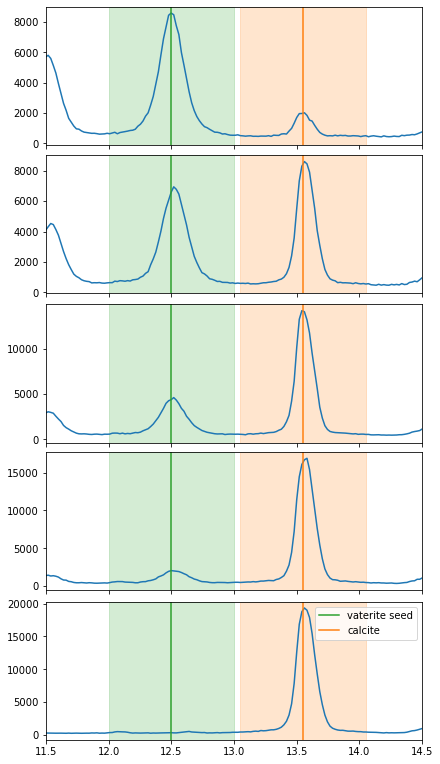

In [13]:
fig, axs = plt.subplots(len(patterns), 1, figsize=[6, len(patterns) * 2.1], sharex=True, constrained_layout=True)

for ax, key in zip(axs, order):
    dat = patterns[key]
    ax.plot(dat.Angle, dat.PSD)
    ax.set_xlim(11.5, 14.5)
    
    ax.axvline(vat_2theta, color='C2', label='vaterite seed')
    ax.axvspan(vat_2theta - window, vat_2theta + window, color='C2', alpha=0.2)
    
    ax.axvline(cal_2theta, color='C1', label='calcite')
    ax.axvspan(cal_2theta - window, cal_2theta + window, color='C1', alpha=0.2)
axs[-1].legend()

In [14]:
def pkfn(angle, position, height, sigma, gamma, background):
    shape = voigt_profile(angle - position, sigma, gamma)
    shape /= shape.max()
    return height * shape + background

def fit_peak(dat, location, window=0.5):

    sub = dat.loc[(dat.Angle >= location - window) & (dat.Angle <= location + window)]
    p0 = (
        location, 
        sub.loc[abs(sub.Angle - location) == min(abs(sub.Angle - location)), 'PSD'].item() - sub['PSD'].iloc[0],
        .1,
        .1,
        sub['PSD'].iloc[0]
    )
    
    return curve_fit(pkfn, sub.Angle, sub.PSD, p0=p0)

In [15]:
vat_fits = {}
cal_fits = {}
for k, dat in patterns.items():
    vat_fits[k] = fit_peak(dat, vat_2theta, window)
    cal_fits[k] = fit_peak(dat, cal_2theta, window)

# plt.plot(sub.Angle, fitfn(sub.Angle, *p))
# plt.scatter(sub.Angle, sub.PSD, s=50, marker='+', color=(0,0,0,0.4))

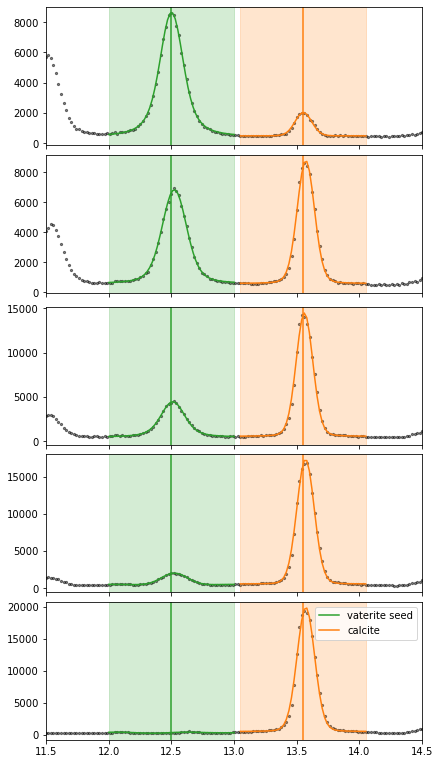

In [16]:
fig, axs = plt.subplots(len(patterns), 1, figsize=[6, len(patterns) * 2.1], sharex=True, constrained_layout=True)

for ax, k in zip(axs, order):
    dat = patterns[k]
    ax.scatter(dat.Angle, dat.PSD, s=5, color=(0,0,0,0.5))
    ax.set_xlim(11.5, 14.5)
    
    ax.axvline(vat_2theta, color='C2', label='vaterite seed')
    ax.axvspan(vat_2theta - window, vat_2theta + window, color='C2', alpha=0.2)
    
    xn = np.linspace(vat_2theta - window, vat_2theta + window)
    ax.plot(xn, pkfn(xn, *vat_fits[k][0]), color='C2')
    
    ax.axvline(cal_2theta, color='C1', label='calcite')
    ax.axvspan(cal_2theta - window, cal_2theta + window, color='C1', alpha=0.2)
    
    xn = np.linspace(cal_2theta - window, cal_2theta + window)
    ax.plot(xn, pkfn(xn, *cal_fits[k][0]), color='C1')
    
axs[-1].legend()

In [17]:
# calculate areas
vat_areas = {}
for k, (p, cov) in vat_fits.items():
    xn = np.linspace(vat_2theta - window, vat_2theta + window)
    yn = pkfn(xn, *p)
    yn -= p[-1]
    vat_areas[k] = np.trapz(yn, xn)

vat_areas['100_calcite_0_vaterite'] = 0
    
cal_areas = {}
for k, (p, cov) in cal_fits.items():
    xn = np.linspace(cal_2theta - window, cal_2theta + window)
    yn = pkfn(xn, *p)
    yn -= p[-1]
    cal_areas[k] = np.trapz(yn, xn)

## Regression

In [19]:
dat = pd.read_csv('Data/calcite_seed_mixtures.csv')

In [20]:
for i, k in enumerate(order[::-1]):
    dat.loc[i, 'A_C104'] = cal_areas[k]
    dat.loc[i, 'A_V101'] = vat_areas[k]

In [21]:
dat['R_Areas'] = dat.A_V101 / dat.A_C104

In [22]:
dat

,mg_calcite,mg_seed,I_C104,I_V101,A_C104,A_V101,R_Areas
0,20.00,0.00,19299,0,3516.873286,1.124141,0.000320
1,15.00,4.84,16972,1954,2984.055809,340.846792,0.114223
2,10.11,10.62,14149,4322,2392.931082,1078.491213,0.450699
3,4.96,14.90,8643,6393,1469.045489,1681.673428,1.144739
4,0.00,20.39,2013,8584,264.381876,2238.841736,8.468212


In [23]:
dat['F_seed'] = dat.mg_seed / (dat.mg_seed + dat.mg_calcite)
dat['R_seed'] = dat.mg_seed / dat.mg_calcite

In [24]:
dat

,mg_calcite,mg_seed,I_C104,I_V101,A_C104,A_V101,R_Areas,F_seed,R_seed
0,20.00,0.00,19299,0,3516.873286,1.124141,0.000320,0.000000,0.000000
1,15.00,4.84,16972,1954,2984.055809,340.846792,0.114223,0.243952,0.322667
2,10.11,10.62,14149,4322,2392.931082,1078.491213,0.450699,0.512301,1.050445
3,4.96,14.90,8643,6393,1469.045489,1681.673428,1.144739,0.750252,3.004032
4,0.00,20.39,2013,8584,264.381876,2238.841736,8.468212,1.000000,inf


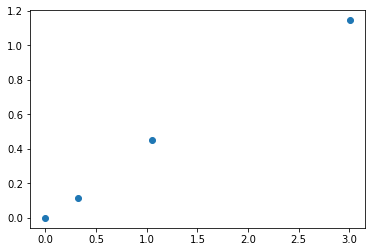

In [25]:
plt.scatter(dat.R_seed, dat.R_Areas)

## Fit $f$ and $a$

In [26]:
def fitfn(F_seed, f, a):
    return a * (F_seed * f) / ((1 - F_seed) + (1 - f) * F_seed)

In [27]:
p, cov = curve_fit(fitfn, dat.F_seed, dat.R_Areas, p0=(0.95, 8/100))

In [28]:
import uncertainties as un
import uncertainties.unumpy as unp

In [29]:
up = un.correlated_values(p, cov)

In [30]:
up

(0.9479041580662901+/-0.0007903859583189384,
 0.46540435225009447+/-0.007373371503429684)

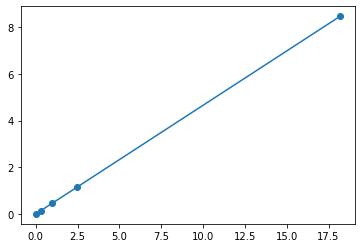

In [31]:
f = p[0]
RM = (dat.F_seed * f) / ((1 - dat.F_seed) + (1 - f) * dat.F_seed)
plt.scatter(RM, dat.A_V101 / dat.A_C104)

xn = np.linspace(0, 18)
plt.plot(xn, xn * p[1])

In [32]:
predR = dat.R_Areas / up[1]
predF = predR / (1 + predR)

In [33]:
predF

0    0.000686+/-0.000011
1        0.1971+/-0.0025
2          0.492+/-0.004
3        0.7110+/-0.0033
4        0.9479+/-0.0008
Name: R_Areas, dtype: object